In [2]:
import pandas as pd
import numpy as np  

data=pd.read_csv("CC GENERAL.csv")
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
def tensor_product(p, q, r):

    # Ensure inputs are numpy arrays
    p = np.asarray(p)
    q = np.asarray(q)
    r = np.asarray(r)

    # Reshape vectors for broadcasting and compute the outer product
    tensor_3d = p[:, None, None] * q[None, :, None] * r[None, None, :]

    return tensor_3d

import numpy as np

# cache matrix-nullSpaceSolution to avoid recomputation
matrix_nullSpaceSolution = {}

def findNullSpace(A):
    # flatten tupple A
    B=  A.flatten()
    if tuple(B) in matrix_nullSpaceSolution:
        return matrix_nullSpaceSolution[tuple(B)]
    # Compute the SVD of A
    U, S, Vt = np.linalg.svd(A)

    # Find the null space of A
    null_space = Vt.T[:, S.size:]

    # Choose a non-trivial vector from the null space
    non_trivial_solution = null_space[:, 0]
    # Cache the result
    matrix_nullSpaceSolution[tuple(B)] = non_trivial_solution
    return non_trivial_solution
    # return Vt[-1]




def caratheodory(P, w):
    assert len(P) == len(w)
    n, d = P.shape
    if n <= d + 1:
        return P, w
    weigtedSumOfPoints = np.dot(w, P)
    # Compute the matrix M (each column is pi - p1)
    M = (P[1:] - P[0]).T  # shape (d, n-1)
    v= findNullSpace(M)   
    v1 = -np.sum(v)
    v = np.insert(v, 0, v1)

    alpha = np.inf
    for i in range(n):
        if v[i] > 0:
            alpha = min(alpha, w[i] / v[i])
    u = w - alpha * v
    assert np.all(u >= -0.0000001)
    S = P[u > 0]
    u = u[u > 0]
    weightedSumOfPoints2 = np.dot(u, S)
    assert np.allclose(weigtedSumOfPoints, weightedSumOfPoints2)
    if len(S) > d + 1:
        return caratheodory(S, u)  # Recursive call if needed
    return S, u


# write the function for k-streaming algorithm based caraheodory algorithm (take d+2 points and keep reducing the points)


def streaming_caratheodory(P, w, d):

    n = len(P)
    selected_points = P[:d+1]
    selected_weights = w[:d+1]
    
    for i in range(d+1, n):

        selected_points = np.vstack((selected_points, P[i]))
        selected_weights = np.append(selected_weights, w[i])
        
        # Apply Caratheodory's theorem to reduce the set to d+1 points
        selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights))
    
    return selected_points, selected_weights



In [4]:
from sklearn.preprocessing import StandardScaler, normalize

scaler = StandardScaler()
data=data.drop('CUST_ID',axis=1)
data=data.dropna()
# data = scaler.fit_transform(data)
data = normalize(data)

data.shape
data=data
data=pd.DataFrame(data)
data.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.039353,0.000787,0.091790,0.000000,0.091790,0.00000,0.000160,0.000000,0.000080,0.000000,0.000000,0.001924,0.962156,0.194165,0.134230,0.00000,0.011546
1,0.293876,0.000083,0.000000,0.000000,0.000000,0.59124,0.000000,0.000000,0.000000,0.000023,0.000367,0.000000,0.642358,0.376516,0.098404,0.00002,0.001101
2,0.310798,0.000125,0.096307,0.096307,0.000000,0.00000,0.000125,0.000125,0.000000,0.000000,0.000000,0.001495,0.934206,0.077485,0.078135,0.00000,0.001495
3,0.504284,0.000617,0.009867,0.009867,0.000000,0.00000,0.000051,0.000051,0.000000,0.000000,0.000000,0.000617,0.740040,0.418329,0.150963,0.00000,0.007400
4,0.428658,0.000237,0.315788,0.000000,0.315788,0.00000,0.000158,0.000000,0.000138,0.000000,0.000000,0.001895,0.426330,0.331604,0.570156,0.00000,0.002842


In [5]:
data.shape

(8636, 17)

In [6]:
data=np.array(data)
def compute_M2(x_samples, sigma_squared):
    E_x_outer = np.mean([np.outer(x, x) for x in x_samples], axis=0)
    dim = x_samples.shape[1]
    I = np.eye(dim)
    M2 = E_x_outer - sigma_squared * I
    return M2
def compute_EX2(x_samples):
    E_x_outer = np.mean([np.outer(x, x) for x in x_samples], axis=0)
    dim = x_samples.shape[1]
    return E_x_outer

ExOuter=compute_EX2(data)
# subtract Ex@EX from ExOuter
Ex=np.mean(data,axis=0)
Ex=np.outer(Ex,Ex)
ExOuter=ExOuter-Ex
# calculate sigma squared as the smallest eigenvalue of the covarriacnce matrix Exouter
sigma_squared = np.linalg.eigvals(ExOuter).min()


# sigma_squared = np.var(data, axis=0).min()
M2=compute_M2(data, sigma_squared)

sigma_squared

3.071891504472829e-10

In [7]:
def calculate_whitening_matrix(M2, k):
    _, Sigma, VT= np.linalg.svd(M2)
    sigma=Sigma[:k]
    sigma_inv_root = np.diag(1. / np.sqrt(sigma))
    VT=VT[:k, :] 
    W = VT.T @ sigma_inv_root   
    return W
k=4
W=calculate_whitening_matrix(M2, k)
print(W.T@M2@W)


[[ 1.00000000e+00  1.04265025e-15 -3.53536248e-16 -4.76205482e-16]
 [ 8.88156330e-16  1.00000000e+00 -2.69006286e-16 -3.52014819e-16]
 [-3.52808836e-16 -1.69003235e-16  1.00000000e+00 -3.92261022e-16]
 [-2.31703239e-16 -2.44430027e-16 -2.88982687e-16  1.00000000e+00]]


#   Normal M3_tilda calculation


In [8]:
import numpy as np
import time

# Assuming 'data' is an (n_samples, n_features) matrix and W is the whitening matrix
n_samples, n_features = data.shape

# Compute the mean of the data and the whitened mean
Ex = np.mean(data, axis=0)  # Empirical mean of the data (n_features,)
Ex_tilda = Ex @ W  # Whitened mean

# Initialize M3_tilda to store the results
M3_tilda = np.zeros((k, k, k))  # (n_features x n_features x n_features)
tensor_list = []
# Loop over all data points to compute both the third-order moment and the correction term
for i in range(n_samples):
    whitened_row = data[i] @ W  # Whiten the current row

    # First term: x_i ⊗ x_i ⊗ x_i
    row_i = tensor_product(whitened_row, whitened_row, whitened_row)

    # Second term: Correction involving the mean
    row_i -= sigma_squared * (
        tensor_product(Ex_tilda, whitened_row, whitened_row) +
        tensor_product(whitened_row, Ex_tilda, whitened_row) +
        tensor_product(whitened_row, whitened_row, Ex_tilda)
    )
    M3_tilda += row_i  # Add the current row to the total
    tensor_list.append(row_i.flatten()) 

# Finally, divide by the number of samples to get the mean
# M3_tilda /= n_samples
m3_start_orignal = time.perf_counter()
M3_tilda1=M3_tilda = np.zeros((k, k, k)).flatten()
for i in tensor_list:
    M3_tilda1+=i
M3_tilda1=M3_tilda1/n_samples
M3_tilda1=M3_tilda1.reshape((k,k,k))
m3_end_orignal = time.perf_counter()
m3_time_orignal = m3_end_orignal - m3_start_orignal

M3_tilda=M3_tilda1
# M3_tilda now contains the final value of the modified M3 matrix


#   Calculating M3_tilda using accurate coreset

In [9]:
# import comb
from scipy.special import comb
tensor_list = np.array(tensor_list)
# print(tensor_list.shape)
print(np.linalg.matrix_rank(tensor_list))
weights=np.ones(tensor_list.shape[0])/tensor_list.shape[0]
accurate_coreset, new_weights=streaming_caratheodory(tensor_list, weights, k*(k+1)*(k+2)//6)
accurate_coreset=np.array(accurate_coreset)
accurate_coreset.shape

20


(65, 64)

In [10]:
# caculate the weighted mean of the coresets using new_weights
m3_start_coreset = time.perf_counter()
weighted_coreset=np.zeros(accurate_coreset[0].shape)
for i in range(accurate_coreset.shape[0]):
    weighted_coreset+=accurate_coreset[i]*new_weights[i]
# weighted_coreset.shape
# convert the weighted_coreset to the original space
weighted_coreset=weighted_coreset.reshape(k,k,k)
m3_end_coreset = time.perf_counter()
m3_time_coreset = m3_end_coreset - m3_start_coreset
# print(m3_time_orignal*1000, m3_time_coreset*1000)
print(f"Time taken to compute M3_tilda using original method: {m3_time_orignal*1000:.2f} ms")
print(f"Time taken to compute M3_tilda using coreset method: {m3_time_coreset*1000:.2f} ms")
weighted_coreset[0]

Time taken to compute M3_tilda using original method: 7.86 ms
Time taken to compute M3_tilda using coreset method: 1.60 ms


array([[-1.01662455, -0.03692467, -0.04570537, -0.00536938],
       [-0.03692467, -0.97396686,  0.01146983,  0.01071614],
       [-0.04570537,  0.01146983, -0.90057059,  0.00319445],
       [-0.00536938,  0.01071614,  0.00319445, -0.89754607]])

In [11]:
M3_tilda[0]

array([[-1.01662455, -0.03692467, -0.04570537, -0.00536938],
       [-0.03692467, -0.97396686,  0.01146983,  0.01071614],
       [-0.04570537,  0.01146983, -0.90057059,  0.00319445],
       [-0.00536938,  0.01071614,  0.00319445, -0.89754607]])

In [12]:

def robust_tensor_power_method(T, L, N): 
    k = T.shape[0]  # Dimension of the tensor
    
    # Step 1: Initialize storage for eigenvalue estimates
    eigenvalue_estimates = np.zeros(L)
    eigenvector_estimates = np.zeros((L, k))
    
    # Step 2: Perform L trials with random initial vectors
    for tau in range(L):
        # Step 2.1: Draw a random initial vector θ(τ)_0 from the unit sphere in R^k
        theta = np.random.randn(k)
        theta /= np.linalg.norm(theta)  # Normalize to make it on the unit sphere
        
        # Step 2.2: Perform N power iterations
        for t in range(N):
            # Compute T(I, θ, θ)
            theta_new = np.tensordot(T, np.outer(theta, theta), axes=([1, 2], [0, 1]))
            # Normalize the resulting vector
            theta_new /= np.linalg.norm(theta_new)
            theta = theta_new
        
        # Store the result of the final power iteration
        eigenvector_estimates[tau] = theta
        # Correct calculation of eigenvalue using einsum
        eigenvalue_estimates[tau] = np.einsum('ijk,i,j,k', T, theta, theta, theta)
    
    # Step 3: Find the best eigenvector/eigenvalue pair
    best_index = np.argmax(eigenvalue_estimates)
    estimated_eigenvector = eigenvector_estimates[best_index]
    estimated_eigenvalue = eigenvalue_estimates[best_index]
    
    # Step 4: Further refine the estimate with additional N iterations
    theta = estimated_eigenvector
    for _ in range(N):
        theta_new = np.tensordot(T, np.outer(theta, theta), axes=([1, 2], [0, 1]))
        theta_new /= np.linalg.norm(theta_new)
        theta = theta_new
    estimated_eigenvector = theta
    # Correct calculation of refined eigenvalue using einsum
    estimated_eigenvalue = np.einsum('ijk,i,j,k', T, theta, theta, theta)
    
    # Step 5: Deflate the tensor
    # Correct calculation of the rank-1 tensor using einsum
    estimated_eigenvector_outer = np.einsum('i,j,k->ijk', estimated_eigenvector, estimated_eigenvector, estimated_eigenvector)
    deflated_tensor = T - estimated_eigenvalue * estimated_eigenvector_outer
    
    return estimated_eigenvector, estimated_eigenvalue, deflated_tensor

L = 10  # Number of trials
N = 10  # Number of power iterations



In [13]:
estimated_eigenvectors1 = []
estimated_eigenvalues1 = []
deflated_tensors1 = []
deflated_tensor1=M3_tilda 
ori_s1 = time.perf_counter()
for _ in range(k):
    estimated_eigenvector1, estimated_eigenvalue1, deflated_tensor1 = robust_tensor_power_method(deflated_tensor1, L, N)
    estimated_eigenvectors1.append(estimated_eigenvector1)
    estimated_eigenvalues1.append(estimated_eigenvalue1)
    deflated_tensors1.append(deflated_tensor1)
ori_e1 = time.perf_counter()


print(estimated_eigenvectors1)
print(estimated_eigenvalues1)


[array([-0.44159471,  0.52013138,  0.18475343,  0.70733558]), array([-0.48601174, -0.04805249,  0.85516463, -0.1737153 ]), array([-0.561028  ,  0.54452154, -0.18885744, -0.59420261]), array([-0.72066391, -0.63096556, -0.2636116 ,  0.11417053])]
[2.0445126953368535, 1.746482766932526, 1.6430915139852555, 1.4158438033123486]


In [14]:
estimated_eigenvectors2 = []
estimated_eigenvalues2 = []
deflated_tensors2 = []
deflated_tensor2 = weighted_coreset
coreset_s1 = time.perf_counter()
for _ in range(k):
    estimated_eigenvector2, estimated_eigenvalue2, deflated_tensor2 = robust_tensor_power_method(deflated_tensor2, L, N)
    estimated_eigenvectors2.append(estimated_eigenvector2)  # Append the vector to the list
    estimated_eigenvalues2.append(estimated_eigenvalue2)    # Append the value to the list
    deflated_tensors2.append(deflated_tensor2)             # Append the tensor to the list
coreset_e1 = time.perf_counter()

print(estimated_eigenvectors2)
print(estimated_eigenvalues2)


[array([-0.44159491,  0.52013245,  0.18474997,  0.70733558]), array([-0.4860106 , -0.04805623,  0.85516688, -0.17370637]), array([-0.56102831,  0.5445206 , -0.18885393, -0.5942043 ]), array([-0.72066381, -0.63096538, -0.26361236,  0.11417045])]
[2.04451269534157, 1.7464836694225143, 1.6430930212083046, 1.4158436142238253]


In [16]:
W_T = W.T
W_pseudo_inv = np.linalg.pinv(W_T)

def recover_original_distributions(estimated_eigenvectors, estimated_eigenvalues, W_pseudo_inv):
    recovered_centroids = []
    
    for i in range(len(estimated_eigenvectors)):
        estimated_eigenvector = estimated_eigenvectors[i]
        estimated_eigenvalue = estimated_eigenvalues[i]
        
        original_eigenvector =estimated_eigenvalue*W_pseudo_inv @ estimated_eigenvector
        
        recovered_centroids.append(original_eigenvector)

    
    return recovered_centroids

recovered_centroids1 = recover_original_distributions(estimated_eigenvectors1, estimated_eigenvalues1, W_pseudo_inv)

recovered_centroids2 = recover_original_distributions(estimated_eigenvectors2, estimated_eigenvalues2, W_pseudo_inv)


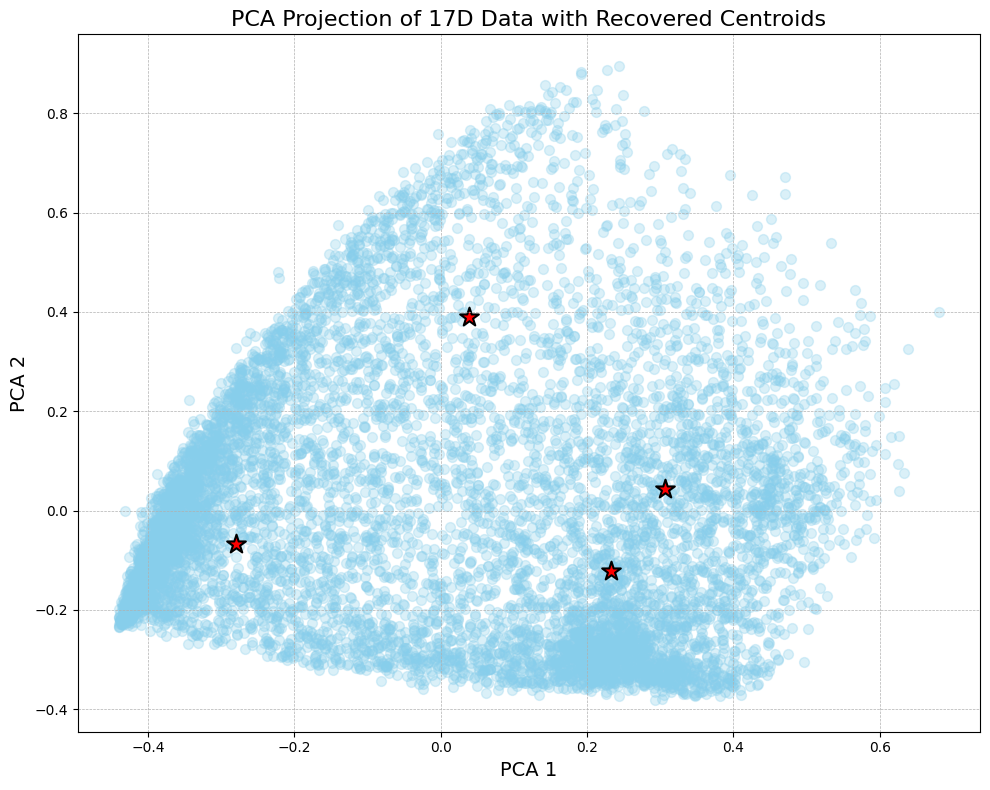

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA to reduce the 17-dimensional data to 2 dimensions
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)  # Transform the original data
centroids_2d = pca.transform(recovered_centroids1)  # Transform the centroids

# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot for the PCA-transformed data in 2D
ax.scatter(data_2d[:, 0], data_2d[:, 1], c='skyblue', alpha=0.3, s=50, label='Original Data')

# Plot the PCA-transformed centroids in 2D
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=200, c='red', marker='*', edgecolor='black', linewidth=1.5, label='Recovered Centroid 1')

# Set axis labels and title with bigger font sizes
ax.set_xlabel('PCA 1', fontsize=14)
ax.set_ylabel('PCA 2', fontsize=14)
ax.set_title('PCA Projection of 17D Data with Recovered Centroids', fontsize=16)

# Add a grid for better readability
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Place the legend outside the plot to avoid cluttering
# ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the final plot
plt.tight_layout()
plt.show()


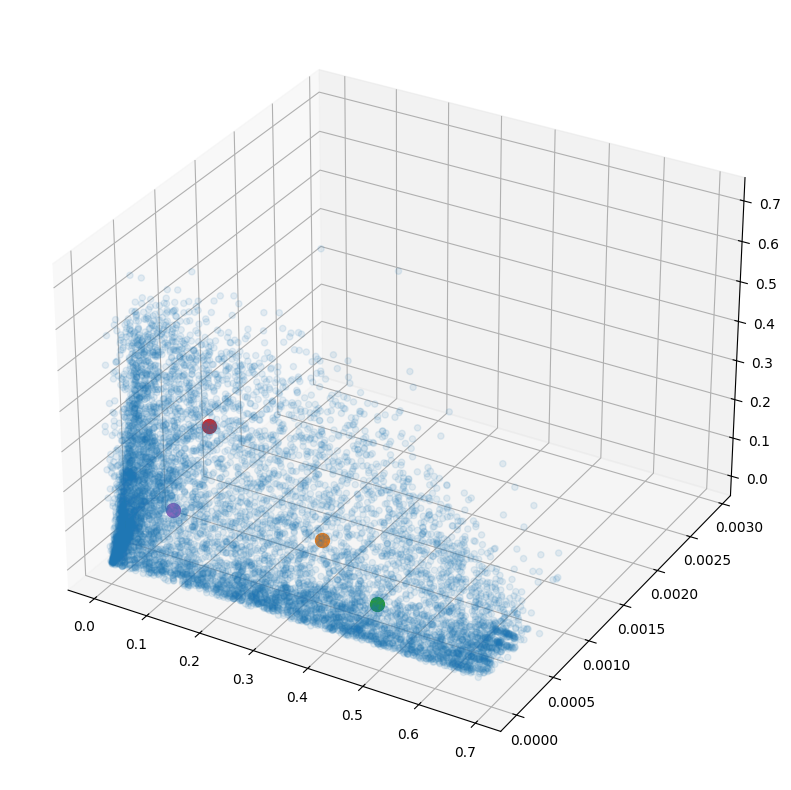

In [18]:
# calculate three centers using k means clustering and then plot the data with the centers named as means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)

kmeans.fit(data)
y_kmeans = kmeans.predict(data)
centers = kmeans.cluster_centers_

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the original data
ax.scatter(data[:, 0], data[:, 1], data[:, 2], alpha=0.1, label='Original Data')

# Plot the recovered centroids
for centroid in centers:
    ax.scatter(centroid[0], centroid[1], centroid[2], s=100, label='Recovered Centroids2')



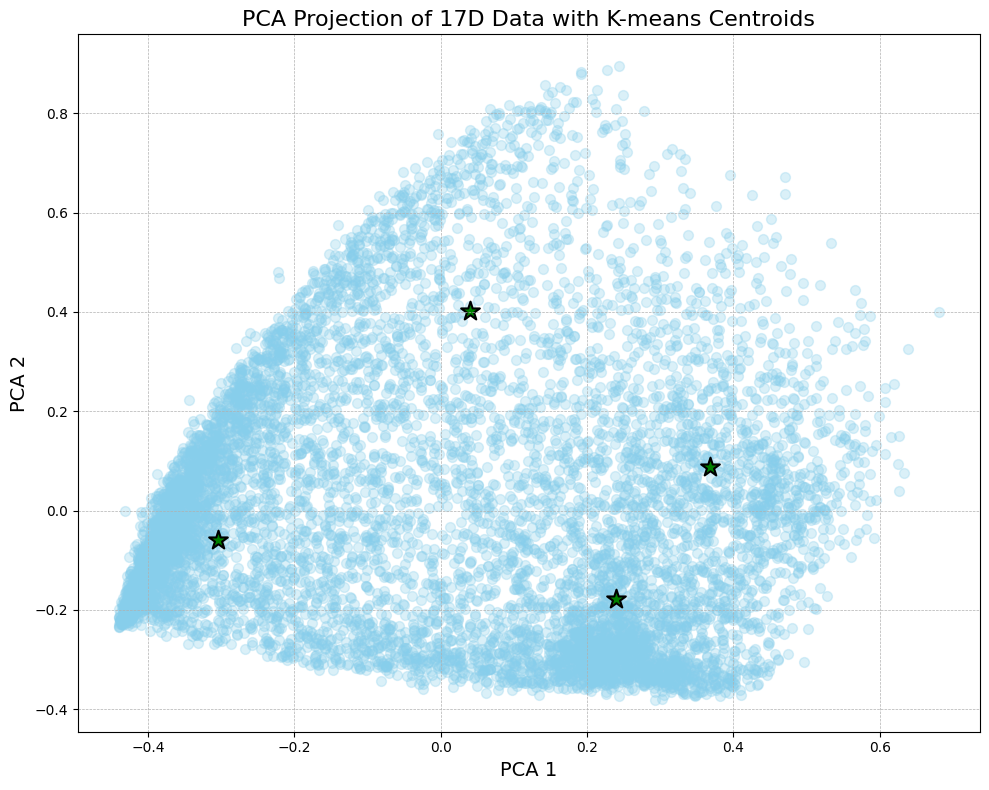

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA to reduce the 17-dimensional data to 2 dimensions
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)  # Transform the original data
centroids_2d = pca.transform(centers)  # Transform the centroids

# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot for the PCA-transformed data in 2D
ax.scatter(data_2d[:, 0], data_2d[:, 1], c='skyblue', alpha=0.3, s=50, label='Original Data')

# Plot the PCA-transformed centroids in 2D
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=200, c='green', marker='*', edgecolor='black', linewidth=1.5, label='K-means Centroid 1')

# Set axis labels and title with bigger font sizes
ax.set_xlabel('PCA 1', fontsize=14)
ax.set_ylabel('PCA 2', fontsize=14)
ax.set_title('PCA Projection of 17D Data with K-means Centroids', fontsize=16)

# Add a grid for better readability
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Place the legend outside the plot to avoid cluttering
# ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the final plot
plt.tight_layout()
plt.show()


In [20]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min

# Assuming data is a NumPy array of shape (n_samples, n_features)
# method_1_centers and method_2_centers are the cluster centers you calculated

def kmeans_loss(data, cluster_centers):
    # Assign each point to the nearest cluster center
    closest_clusters, distances = pairwise_distances_argmin_min(data, cluster_centers)
    
    # Calculate the sum of squared distances (K-means loss)
    loss = np.sum(distances**2)
    
    return loss

# Calculate loss for both methods
loss_method_1 = kmeans_loss(data, recovered_centroids1)
loss_method_2 = kmeans_loss(data, centers)
loss_method_3=kmeans_loss(data, recovered_centroids2)

# Output the losses
print(f"K-means Loss for GMM on entire data: {loss_method_1}")
print(f"K-means Loss  for GMM on coreset data: {loss_method_3}")
print(f"K-means Loss for K-means clustering: {loss_method_2}")



K-means Loss for GMM on entire data: 1025.9320705391895
K-means Loss  for GMM on coreset data: 1025.9317444342046
K-means Loss for K-means clustering: 1045.7011347060156
